In [67]:
"""
Cleaned up version of the integration imports we need to actually run this code together.
"""

import numpy as np
from scipy import signal
from optic.models.devices import mzm, photodiode, edfa, iqm, coherentReceiver, pdmCoherentReceiver, basicLaserModel
from optic.models.channels import linearFiberChannel, ssfm
from optic.comm.modulation import modulateGray, grayMapping
from optic.comm.sources import bitSource, symbolSource
from optic.dsp.core import upsample, pulseShape, pnorm, anorm, signalPower, firFilter, decimate, symbolSync,phaseNoise

try:
    from optic.dsp.coreGPU import checkGPU
    if checkGPU():
        from optic.dsp.coreGPU import firFilter
    else:
        from optic.dsp.core import firFilter
except ImportError:
    from optic.dsp.core import firFilter

from optic.utils import parameters, dBm2W, ber2Qfactor
from optic.plot import eyediagram, pconst, plotPSD
import matplotlib.pyplot as plt
from scipy.special import erfc
from tqdm.notebook import tqdm
import scipy as sp
import scipy.constants as const

try:
    from optic.models.modelsGPU import manakovSSF
except:
    from optic.models.channels import manakovSSF

from optic.dsp.equalization import edc, mimoAdaptEqualizer, ffe
from optic.dsp.carrierRecovery import cpr, ddpll,fourthPowerFOE
from optic.comm.metrics import fastBERcalc, monteCarloGMI, monteCarloMI, calcEVM, bert
from optic.dsp.clockRecovery import gardnerClockRecovery


import logging as logg
logg.basicConfig(level=logg.INFO, format='%(message)s', force=True)
import time

In [68]:
# --------------------------------------------------------------------------------------------------------------------------------------
# Power Amplifier (PA) Functions
# ---------------------------------------------------------------------------------------------------------------------------------------

def rapp_pa(x, Vsat, p=2.0):
    """
    Memoryless Rapp PA model for complex baseband input.

    Parameters
    ----------
    x : np.ndarray
        Complex input waveform in volts.
    Vsat : float
        Saturation voltage/amplitude.
    p : float
        Rapp smoothness exponent.

    Returns
    -------
    y : np.ndarray
        Output after memoryless PA nonlinearity.
    """
    mag = np.abs(x)
    gain = 1.0 / (1.0 + (mag / Vsat) ** (2 * p)) ** (1.0 / (2 * p))
    return x * gain


def butter_lpf_complex(x, Fs, f3dB, order=3):
    """
    Apply an order-N Butterworth LPF to a complex baseband waveform.
    """
    wn = f3dB / (Fs / 2)

    if wn >= 1.0:
        raise ValueError(
            f"Butterworth cutoff must be below Nyquist. Got f3dB={f3dB/1e9:.2f} GHz, "
            f"Fs/2={(Fs/2)/1e9:.2f} GHz."
        )

    b, a = signal.butter(order, wn, btype='low')

    y_i = signal.lfilter(b, a, np.real(x))
    y_q = signal.lfilter(b, a, np.imag(x))

    return y_i + 1j * y_q


def pa_model_physical(x, Fs, gain_linear, BLPF_enable, BO_dB=5.0, p=2.0, f3dB=10e9, order=3):
    """
    Physical PA model:
        x -> linear gain -> Rapp compression -> Butterworth LPF

    Parameters
    ----------
    x : np.ndarray
        Complex baseband input waveform (dimensionless DSP waveform).
    Fs : float
        Sample rate [Hz].
    gain_linear : float
        Small-signal linear voltage gain. This sets the nominal IQM drive level.
    BO_dB : float
        Back-off in dB, used to set Vsat relative to the RMS value AFTER gain.
    p : float
        Rapp exponent.
    f3dB : float
        PA 3-dB bandwidth [Hz].
    order : int
        Butterworth filter order.

    Returns
    -------
    y : np.ndarray
        PA output waveform in volts, ready to drive the IQM.
    info : dict
        Diagnostic information.
    """

    # 1) Linear gain stage -> now waveform is in volts
    x_amp = gain_linear * x

    # 2) Compute RMS after gain
    Vrms_in = np.sqrt(np.mean(np.abs(x_amp) ** 2))

    # 3) Saturation voltage from back-off
    Vsat = Vrms_in * 10 ** (BO_dB / 20)

    # 4) Nonlinear compression
    y_nl = rapp_pa(x_amp, Vsat=Vsat, p=p)

    # 5) PA bandwidth limitation
    if BLPF_enable:
        y = butter_lpf_complex(y_nl, Fs=Fs, f3dB=f3dB, order=order)
    else:
        y = y_nl

    info = {
        "gain_linear": gain_linear,
        "Vrms_in_V": Vrms_in,
        "Vsat_V": Vsat,
        "BO_dB": BO_dB,
        "p": p,
        "f3dB_Hz": f3dB,
        "peak_out_V": np.max(np.abs(y)),
        "rms_out_V": np.sqrt(np.mean(np.abs(y) ** 2)),
    }

    return y, info

In [69]:
# --------------------------------------------------------------------------------------------------------------------------------------
# Parameters Configuration of Optical System
# ---------------------------------------------------------------------------------------------------------------------------------------


# -----------------------------------------------
# Transmitter Parameters
#-------------------------------------------------

# 1) General Parameters
SpS = 16                 # samples per symbol
Rs = 32e9                # symbol rate [baud]
Fs = Rs * SpS            # sampling frequency [Hz]
M = 16                   # QPSK -> M=4, constType='qam'
nBits = 400000           # total bits to generate
rollOff = 0.01           # RRC roll-off
nFilterTaps = 1024       # RRC filter taps
mzmScale = 0.5           # IQM drive scale = "modulation depth" (0.5 is default in OptiCommPy)
Vpi = 2                  # IQM pi Voltage  (2V is defualt in OpticommPy)
P_launch_dBm = 0         # desired launched optical power [dBm] -- for 4QAM try 6 dbm -- for 16QAM 0 was good
laserLinewidth = 100e3   # Hz (set e.g. 100e3 for phase noise), setting laserLineWidth to 0, models the ideal case 

# 2) Symbol Source Parameters
paramSymb = parameters()
paramSymb.nSymbols = int(nBits // np.log2(M))  # symbols = bits / log2(M)
paramSymb.M = M
paramSymb.constType = "qam"                    # 'qam' with M=4 -> QPSK
paramSymb.dist = "uniform"                     # uniform symbol probabilities
paramSymb.seed = 444
paramSymb.shapingFactor = 0

constSymb = grayMapping(paramSymb.M, paramSymb.constType)
if paramSymb.dist == "uniform":
   px = np.ones(paramSymb.M) / paramSymb.M
elif paramSymb.probDist == "maxwell-boltzmann":
   px = np.exp(-paramSymb.shapingFactor * np.abs(constSymb) ** 2)
   px = px / np.sum(px)
else:
   raise ValueError("Invalid probability distribution.")
paramSymb.px = px

# 3) UpSampling and FIR Parameters
paramPulse = parameters()
paramPulse.pulseType = "rrc"
paramPulse.nFilterTaps = nFilterTaps
paramPulse.rollOff = rollOff
paramPulse.SpS = SpS

# 4) IQM Parameters
paramIQM = parameters()
paramIQM.Vpi = Vpi
paramIQM.VbI = -Vpi
paramIQM.VbQ = -Vpi
paramIQM.Vphi = Vpi/2

# 5) Optical Carrier / LO field (Ein)
sigTx_length = paramSymb.nSymbols * SpS
if laserLinewidth and laserLinewidth > 0:
    phi_pn = phaseNoise(laserLinewidth, sigTx_length, 1 / Fs, seed=123)
    sigLO = np.exp(1j * phi_pn)
else:
    sigLO = np.ones_like(sigTx, dtype=complex)

# 6) PA parameters 
PA_enable = True    # enable flag. If "False", the PA is skipped
PA_BO_dB = 5        # 7 = weak, 5 = moderate, 3 = strong
PA_p = 2.0           # paper says typically p=2
PA_f3dB = 18.5e9     # frequency of 3 dB
BLPF_enable = True


# -----------------------------------------------
# Channel Parameters
#------------------------------------------------

# 1) Optical Channel Parameters
paramCh = parameters()
paramCh.Ltotal = 80       # total link distance [km]
paramCh.Lspan  = 80        # span length [km]
paramCh.alpha = 0.2        # fiber loss parameter [dB/km]
paramCh.D = 16             # fiber dispersion parameter [ps/nm/km]
paramCh.gamma = 1.3        # fiber nonlinear parameter [1/(W.km)]
paramCh.Fc = 193.1e12      # central optical frequency of the WDM spectrum
paramCh.hz = 0.5           # step-size of the split-step Fourier method [km]
paramCh.prgsBar = True     # show progress bar
paramCh.Fs = Rs*SpS        # sampling rate
paramCh.amp = 'edfa'       # type of amplifiers
paramCh.NF = 4.5           # Noise Figure of each amplirifer [dB]
#paramCh.seed = 456


# -----------------------------------------------
# Receiver Parameters
#------------------------------------------------

# 1) local oscillator (LO) parameters:
FO  = -128e6                 # frequency offset
paramLO = parameters()
paramLO.P =2              # power in dBm
paramLO.lw = 100e3          # laser linewidth
paramLO.RIN_var = 0
paramLO.Fs = Fs
paramLO.seed = 789 # random seed for noise generation
paramLO.freqShift = 0 + FO  # downshift of the channel to be demodulated add frequency offset

# 2) Front-End Parameters and photodiode paramters

# Frontend parameters
paramFE = parameters()
paramFE.Fs = Fs

# Photodiodes parameters
paramPD = parameters()
paramPD.B = Rs
paramPD.Fs = Fs
paramPD.ideal = True
paramPD.seed = 1011

# 3) Pulseshaping in the reciever using rrc filter
paramRxPulse = parameters()
paramRxPulse.SpS = SpS
paramRxPulse.nFilterTaps = nFilterTaps
paramRxPulse.rollOff = rollOff
paramRxPulse.pulseType = "rrc"

# 4) Decimation Parameters
paramDec = parameters()
paramDec.SpSin  = SpS
paramDec.SpSout = 1

# 5) Chromatic Dispersion Parameters
paramEDC = parameters()
paramEDC.L = paramCh.Ltotal
paramEDC.D = paramCh.D
paramEDC.Fc = paramCh.Fc
paramEDC.Rs = Rs
paramEDC.Fs = 2*Rs

# 6) Adaptive Equalization Parameters
paramEq = parameters()
paramEq.nTaps = 35
paramEq.SpS = paramDec.SpSout
paramEq.numIter = 1
paramEq.storeCoeff = False
paramEq.M = M
paramEq.shapingFactor = 0
paramEq.constType = "qam"
paramEq.prgsBar = False

# 8) Carrier and Phase recovery parameters using bps
paramCPR = parameters()
paramCPR.alg = 'bps'
paramCPR.M   = M
paramCPR.constType ="qam"
paramCPR.shapingFactor = 0
paramCPR.N   = 25
paramCPR.B   = 64
paramCPR.returnPhases = True
paramCPR.Ts = 1/Rs


In [70]:
def select_equalizer_mode(M, Data_Aided, paramEq):
    """
    Selects the equalizer algorithm and step sizes 
    based on M, Data_Aided flag, and chosen mode.
    """

    if Data_Aided:
        if M == 4:
            # For QPSK
            paramEq.alg = ['cma', 'cma']
            paramEq.mu  = [5e-3, 1e-3]
        else:
            # For 16-QAM
            paramEq.alg = ['da-rde', 'rde']
            paramEq.mu  = [5e-3, 5e-4]

    else:  # Blind mode
        if M == 4:
            paramEq.alg = ['cma','cma']
            paramEq.mu  = [5e-3, 1e-3]
        else:
            paramEq.alg = ['cma','rde']
            paramEq.mu  = [5e-3, 1e-3]

    return paramEq

In [71]:
def select_cpr_mode(paramCPR, CPR_Mode, Ts, M):
    paramCPR.Ts = Ts
    paramCPR.M  = M
    paramCPR.returnPhases = True

    if CPR_Mode.lower() == "bps":
        paramCPR.alg = "bps"
        # recommended
        paramCPR.N = 25
        paramCPR.B = 64

    elif CPR_Mode.lower() == "ddpll":
        paramCPR.alg = "ddpll"
        # recommended DDPLL parameters
        paramCPR.tau1 = 1/(2*np.pi*10e3)
        paramCPR.tau2 = 1/(2*np.pi*10e3)
        paramCPR.Kv  = 0.1

    else:
        raise ValueError("CPR_Mode must be 'bps' or 'ddpll'")

    return paramCPR

In [72]:
def mmse_equalizer_exact(rx, tx, L=21, reg=1e-4):
    """
    Data-aided MMSE equalizer at 1 SPS.
    rx : received 1-SPS samples
    tx : transmitted 1-SPS symbols (training)
    """

    rx = np.asarray(rx, dtype=np.complex128)
    tx = np.asarray(tx, dtype=np.complex128)

    N = min(len(rx), len(tx))
    rx = rx[:N]
    tx = tx[:N]

    if N <= L:
        raise ValueError("Signal too short")

    # Build regression matrix X
    X = np.zeros((N - L + 1, L), dtype=np.complex128)
    for i in range(L):
        X[:, i] = rx[L-1-i : N-i]

    # Desired samples
    d = tx[L//2 : N - L//2]

    # MMSE solution
    Rxx = X.conj().T @ X
    rxd = X.conj().T @ d

    h = np.linalg.solve(Rxx + reg*np.eye(L), rxd)

    # Apply filter
    y = np.convolve(rx, h, mode='same')

    return y, h

In [73]:
def simulate_optical_system(symbTx, paramSymb, paramPulse, paramIQM, sigLO, 
                            paramCh, paramLO, paramFE, paramPD,
                            paramRxPulse, paramDec, paramEDC, 
                            paramEq, paramCPR,
                            PA_enable=True):

    # --------------------
    # TRANSMITTER
    # --------------------
    pulse = pulseShape(paramPulse)
    symbolsUp = upsample(symbTx, SpS)
    sigTx = firFilter(pulse, symbolsUp)

    # PA scaling
    target_peak_V = mzmScale * Vpi
    peak_sigTx = np.max(np.abs(sigTx))
    if peak_sigTx == 0:
        raise ValueError("sigTx peak is zero")

    gain_linear = target_peak_V / peak_sigTx

    if PA_enable:
        u_drive, _ = pa_model_physical(
            sigTx, Fs=Fs, gain_linear=gain_linear,
            BLPF_enable=BLPF_enable, BO_dB=PA_BO_dB,
            p=PA_p, f3dB=PA_f3dB, order=3
        )
    else:
        u_drive = gain_linear * sigTx

    sigTxo = iqm(sigLO, u_drive, paramIQM)
    sigTxo = np.sqrt(dBm2W(P_launch_dBm)) * pnorm(sigTxo)

    # --------------------
    # CHANNEL
    # --------------------
    sigCh = ssfm(sigTxo, paramCh)

    # --------------------
    # RECEIVER
    # --------------------
    paramLO.Ns = len(sigCh)
    sigLO_Rx = basicLaserModel(paramLO)

    sigRx = coherentReceiver(sigCh, sigLO_Rx, paramFE, paramPD)

    # Matched filter
    pulse = pulseShape(paramRxPulse)
    sigRx = firFilter(pulse, sigRx)

    # Decimate to 1 SPS
    sigRx = decimate(sigRx, paramDec)

    # Chromatic dispersion compensation
    sigRx = edc(sigRx, paramEDC)

    # --------------------
    # SYMBOL ALIGNMENT
    # --------------------
    # ------------ TIMING RECOVERY 1 SPS ------------
    symbRx = symbolSync(sigRx, symbTx, 1)   # correct!
    symbTx = symbTx[:len(symbRx)]

    x = pnorm(symbRx)
    d = pnorm(symbTx)

    # --------------------
    # MMSE EQUALIZATION
    # --------------------
    y_EQ, h = mmse_equalizer_exact(x, d, L=21, reg=1e-4)

    # CPR expects Nx1 matrix
    y_2d = y_EQ[:, None]

    y_CPR, phaseEst = cpr(y_2d, paramCPR)

    return y_CPR.flatten(), d

In [74]:
def perf_calc(symbTx, y_CPR_1, d, M, paramSymb, paramDec):

    """Performance Metric Exploration for Single Polarization
    """

    # remove phase ambiguity for 4-QAM/QPSK
    if M == 16:
        discard = 5000
        ind = np.arange(discard, len(symbTx) - discard)

        d = symbTx

    # now compute metrics (both are 1 sample/symbol and same length)
        BER, SER, SNR = fastBERcalc(y_CPR_1[ind], d[ind], M, 'qam', px = paramSymb.px)
        EVM = calcEVM(y_CPR_1[ind], M, 'qam', d[ind])
        Qfactor = ber2Qfactor(BER[0])

        print(' SER: %.3e,  '%(SER[0]))
        print(' BER: %.3e   '%(BER[0]))
        print(' SNR: %.3f dB'%(SNR[0]))
        print(' EVM: %.3f %%'%(EVM[0]*100))
        print(' Qfactor: %.3f,  '%(Qfactor))

        
    return BER[0], SER[0], SNR[0], EVM[0], Qfactor

In [75]:
symbTx = symbolSource(paramSymb)

# Running the function to check that it works
y_CPR_1, d= simulate_optical_system(symbTx, paramSymb, paramPulse,paramIQM,sigLO, paramCh, paramLO, paramFE, paramPD,paramRxPulse,paramDec
                            ,paramEDC,paramEq,paramCPR, PA_enable=True)


perf_calc(symbTx, y_CPR_1, d, M, paramSymb, paramDec)


discard = 5000
# plot constellations
pconst(y_CPR_1[discard:-discard])

# plotting eye diagrams of sigTx
eyediagram(y_CPR_1.real[discard:-discard], y_CPR_1.real.size-2*discard, paramDec.SpSout, plotlabel='signal at Rx REAL', ptype='fancy')
eyediagram(y_CPR_1.imag[discard:-discard], y_CPR_1.imag.size-2*discard, paramDec.SpSout, plotlabel='signal at Rx IMAGNIARY', ptype='fancy')


  0%|          | 0/1 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
def run_benchmark():
    results = []

    modes_DataAided = [True, False]
    #modes_CPR = [ "ddpll"]
    modes_CPR = ["bps", "ddpll"]

    for da in modes_DataAided:
        for cpr_mode in modes_CPR:

            print("\n===================================================")
            print(f" Running:  Data_Aided={da},   CPR_Mode={cpr_mode}")
            print("===================================================\n")

            # fresh symbol source each run
            symbTx = symbolSource(paramSymb)

            # run system
            y_CPR_1, d, th = simulate_optical_system(
                symbTx, paramSymb, paramPulse, paramIQM, sigLO,
                paramCh, paramLO, paramFE, paramPD, paramRxPulse, paramDec,
                paramEDC, paramEq, paramCPR,
                Data_Aided=da,
                CPR_Mode=cpr_mode
            )

            # performance
            BER, SER, SNR, EVM, Q = perf_calc(symbTx, y_CPR_1, d, M, paramSymb, paramDec)

            discard = 5000
            # plot constellations
            pconst(y_CPR_1[discard:-discard])

            # plotting eye diagrams of sigTx
            eyediagram(y_CPR_1.real[discard:-discard], y_CPR_1.real.size-2*discard, paramDec.SpSout, plotlabel='signal at Rx REAL', ptype='fancy')
            eyediagram(y_CPR_1.imag[discard:-discard], y_CPR_1.imag.size-2*discard, paramDec.SpSout, plotlabel='signal at Rx IMAGNIARY', ptype='fancy')


            results.append({
                "Data_Aided": da,
                "CPR": cpr_mode,
                "BER": BER,
                "SER": SER,
                "SNR": SNR,
                "EVM": EVM,
                "Qfactor": Q
            })

    return results

In [ ]:

results = run_benchmark()

print("\n==================== SUMMARY TABLE ====================\n")
for r in results:
    print(f"DA={r['Data_Aided']}, CPR={r['CPR']}: "
          f"BER={r['BER']:.2e}, SER={r['SER']:.2e}, "
          f"SNR={r['SNR']:.2f} dB, EVM={r['EVM']*100:.1f} %, Q={r['Qfactor']:.2f}")


 Running:  Data_Aided=True,   CPR_Mode=bps



TypeError: simulate_optical_system() got an unexpected keyword argument 'Data_Aided'

  0%|          | 0/1 [00:00<?, ?it/s]

Running CD compensation...
CD filter length: 46 taps, FFT size: 64
Running adaptive equalizer...
da-rde - training stage #0
da-rde pre-convergence training iteration #0
da-rde MSE = 0.022875.
da-rde pre-convergence training iteration #1
da-rde MSE = 0.015463.
rde - training stage #1
rde MSE = 0.012542.
Running frequency offset compensation...
Estimated frequency offset (MHz): [0.24]
Running DDPLL carrier phase recovery...
Estimated linewidth: 186.371 kHz


 SER: 6.667e-05,  
 BER: 1.667e-05   
 SNR: 20.774 dB
 EVM: 0.836 %
 Qfactor: 6.180,  


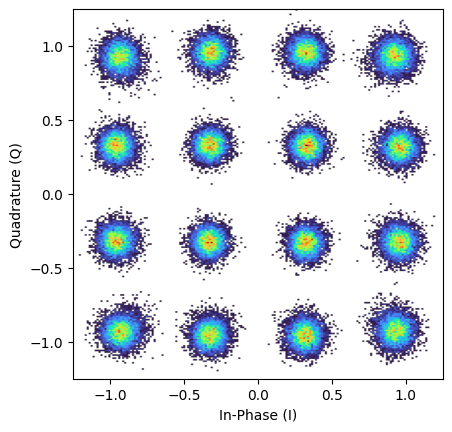

  0%|          | 0/1 [00:00<?, ?it/s]

Running CD compensation...
CD filter length: 46 taps, FFT size: 64
Running adaptive equalizer...
da-rde - training stage #0
da-rde pre-convergence training iteration #0
da-rde MSE = 0.022265.
da-rde pre-convergence training iteration #1
da-rde MSE = 0.015353.
rde - training stage #1
rde MSE = 0.012518.
Running frequency offset compensation...
Estimated frequency offset (MHz): [50.24]
Running DDPLL carrier phase recovery...
Estimated linewidth: 186.763 kHz


 SER: 6.667e-05,  
 BER: 1.667e-05   
 SNR: 20.774 dB
 EVM: 0.836 %
 Qfactor: 6.180,  


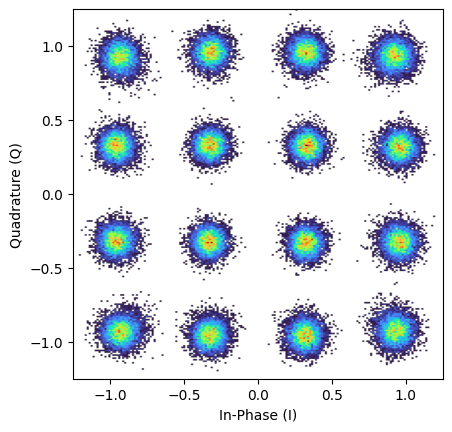

  0%|          | 0/1 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:

linewidths = [10e3, 100e3, 1e6, 5e6]
FO  = [0,-50e6,-128e6]


# Loop over linewidths
for freqShift in FO:
    symbTx = symbolSource(paramSymb)
    
    #print(f"Simulating linewidth: {lw/1e3:.0f} kHz")
    paramLO.lw = 100e3
    # --- Run full optical system simulation ---
    # Here we call your simulate_optical_system function
    # The function must return received signal after CPR
    # Assume symbTx and other parameters are defined globally
    
    paramLO.freqShift = 0 +freqShift
    y_CPR, d, θ= simulate_optical_system(symbTx, paramSymb, paramPulse,paramIQM,sigLO, paramCh, paramLO, paramFE, paramPD,paramRxPulse,paramDec
                            ,paramEDC,paramEq,paramCPR, PA_enable=False, Data_Aided=True)
    perf_calc(symbTx, y_CPR_1, d, M, paramSymb, paramDec)
    
    discard = 5000
    # plot constellations
    pconst(y_CPR_1[discard:-discard])  



